In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from urllib.request import urlopen 
import re
def read_url(url): 
    return re.sub('\\s+', ' ', urlopen(url).read().decode())

# Two types of variables: numerical and categorical
## (numerical = represented with numbers and meaningful to do math on them)

# where predicates

In [2]:
welcome = Table.read_table('welcome_survey_sp22.csv')
# welcome.show(5)
# welcome.num_rows

# What are each type of variable?

In [3]:
# Challenges
## 1. Make a table of just Second Year students called second_years
### second_years = welcome.where('Year','Second')

## 2. Make a table of of all students who get more than 8 hours of sleep. Call it enough_sleep
### enough_sleep = welcome.where('Hours of sleep', are.above(8))

# "are" predictes. See textbook 6.2.5

## 3. Make a table with 2 <= Extroversion <= 4. Call it non_extremes

## 4. Make a table of side sleepers and determine the average number of hours of sleep the side sleepers get

In [4]:
side_sleepers = welcome.where('Sleep position', are.containing('side'))
hours_of_sleep_array = side_sleepers.column('Hours of sleep')
np.average(hours_of_sleep_array)

7.1131167268351385

# Challenge: How many students get 8 or more hours of sleep

In [5]:
# 1.
welcome.where('Hours of sleep', are.above_or_equal_to(8)).num_rows

473

In [6]:
# 2.
hours_of_sleep_array = welcome.column('Hours of sleep')
eight_or_more_hours_array = hours_of_sleep_array >= 8
np.count_nonzero(eight_or_more_hours_array) 
# or
np.sum(eight_or_more_hours_array)

473

In [7]:
# Census
census = Table.read_table('nc-est2019-agesex-res.csv')

In [8]:
## census

# What are each type of variable?
## Be careful: sex is not numberical

# Census taken every 10 years
## 1. Sex = 0,1,2
### 1 = Male, 2 = Femaale, 0 total (Male + Female)
## 2. Age = 100
### Everyone 100 years old or older
## 3. Age = 999
### Sum of all ages

In [9]:
partial = census.select('SEX','AGE','POPESTIMATE2014','POPESTIMATE2019')
partial = partial.relabeled(2,'2014').relabeled(3,'2019')
# partial


In [10]:
# Challenge 
# Number of people in 2014  who are 80 years old, or older
np.sum(partial.where('SEX',0).where('AGE', are.above_or_equal_to(80)).where('AGE',are.below(101)).column('2014'))

11887811

In [11]:
# Remove age = 999, 
below_999 = partial.where('AGE',are.below(999)).where('SEX',0)

In [12]:
# below_999.plot('AGE','2019')
# print('US Population) or plots.title('US Population);
# Why the bump at 100?

In [13]:
males = partial.where('AGE',are.below(999)).where('SEX',1).drop('SEX')
females = partial.where('AGE',are.below(999)).where('SEX',2).drop('SEX')
# males

In [14]:
pop_2019 = Table().with_columns('Age', males.column('AGE'),
                                'Male', males.column('2019'),
                                'Female', females.column('2019'))

In [15]:
# pop_2019.plot('Age')
# More males born than female, females tend to live longer

In [16]:
total = pop_2019.column('Male') + pop_2019.column('Female')
pct_female = np.round((pop_2019.column('Female')/total)*100,2)

In [17]:
# pct_female

# Line Plot

In [18]:
pop_2019 = pop_2019.with_column('Percent Female',pct_female)
# pop_2019
# pop_2019.plot('Age','Percent Female')

In [19]:
# pop_2019.plot('Age','Percent Female')
# plots.ylim(0,100)

# Scatter Plot

In [20]:
actors = Table.read_table('actors.csv')
# actors

# Compare number of movies and total gross. 
# Expected. The more movies an actor makes, the higher the total gross

In [21]:
# actors.scatter('Number of Movies', 'Total Gross')

In [22]:
# actors.scatter('Number of Movies', 'Average per Movie')

# Challenge
## Who is the actor in the top left of the graph?

In [23]:
# actors.where('Average per Movie', are.above(300))

https://en.wikipedia.org/wiki/Anthony_Daniels

In [24]:
top_movies = Table.read_table('top_movies_2017.csv') 
# already sorted by Gross (Adjusted)
top_10 = top_movies.take(np.arange(10))
# top_movies

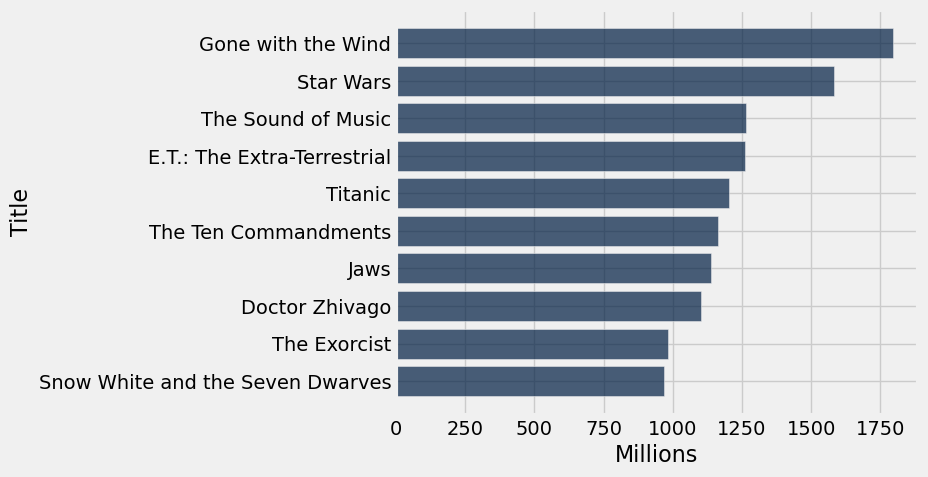

In [28]:
# Convert gross to millions
adjusted_grosses = np.round(top_10.column('Gross (Adjusted)')/1e6,2)
top_10 = top_10.with_column('Millions',adjusted_grosses)
# top_10
top_10.barh('Title', 'Millions')